In [1]:
import os
import numpy as np
import mne
import os
import numpy as np
import mne
import tensorflow as tf
from tensorflow.keras import layers, models

2026-02-27 10:43:17.969288: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def build_eegnet(n_channels, n_times, dropout_rate=0.3):

    input1 = layers.Input(shape=(n_channels, n_times, 1))

    # Temporal convolution
    x = layers.Conv2D(16, (1, 64), padding='same', use_bias=False)(input1)
    x = layers.BatchNormalization()(x)

    # Depthwise spatial convolution
    x = layers.DepthwiseConv2D((n_channels, 1),
                               use_bias=False,
                               depth_multiplier=2,
                               depthwise_constraint=tf.keras.constraints.max_norm(1.))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1, 4))(x)
    x = layers.Dropout(dropout_rate)(x)

    # Separable convolution
    x = layers.SeparableConv2D(32, (1, 16),
                               use_bias=False,
                               padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1, 8))(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs=input1, outputs=x)

In [3]:
data_path = "/Volumes/backup/eeg_sleep_deprivation"
save_path = os.path.expanduser("~/eeg_preprocessed")
os.makedirs(save_path, exist_ok=True)

sfreq_new = 125
epoch_duration = 2.0
epoch_overlap = 0.0   # IMPORTANT: no overlap to reduce memory

subjects = sorted([s for s in os.listdir(data_path) if s.startswith("sub-")])


In [4]:
for subj in subjects:
    print(f"Processing {subj}")
    subj_folder = os.path.join(data_path, subj)

    for ses_num in [1, 2]:
        eeg_folder = os.path.join(subj_folder, f"ses-{ses_num}", "eeg")
        if not os.path.exists(eeg_folder):
            continue

        set_files = [f for f in os.listdir(eeg_folder) if f.endswith(".set")]

        for f in set_files:
            print(f"  Session {ses_num} file {f}")

            try:
                raw = mne.io.read_raw_eeglab(
                    os.path.join(eeg_folder, f),
                    preload=True
                )
            except Exception as e:
                print("ERROR loading:", f)
                print(e)
                continue

            raw.filter(1., 45.)
            raw.set_eeg_reference('average')
            raw.resample(sfreq_new)

            epochs = mne.make_fixed_length_epochs(
                raw,
                duration=epoch_duration,
                overlap=epoch_overlap
            )

            data = epochs.get_data().astype(np.float32)
            labels = np.full(data.shape[0], ses_num - 1, dtype=np.float32)

            # Normalize per epoch per channel
            data = (data - data.mean(axis=2, keepdims=True)) / \
                   (data.std(axis=2, keepdims=True) + 1e-6)

            save_X = os.path.join(save_path, f"{subj}_ses{ses_num}_X.npy")
            save_y = os.path.join(save_path, f"{subj}_ses{ses_num}_y.npy")

            np.save(save_X, data)
            np.save(save_y, labels)

            del raw, epochs, data

print("Preprocessing complete.")

Processing sub-01
  Session 1 file sub-01_ses-1_task-eyesclosed_eeg.set
Reading /Volumes/backup/eeg_sleep_deprivation/sub-01/ses-1/eeg/sub-01_ses-1_task-eyesclosed_eeg.fdt
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (3.302 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
150 matching events found
No baseline correction applied
0 projection items a

/var/folders/g0/6pdwfsr94050v_1mfvlr_ly80000gn/T/ipykernel_4792/829669386.py:16: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/var/folders/g0/6pdwfsr94050v_1mfvlr_ly80000gn/T/ipykernel_4792/829669386.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
150 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 150 events and 250 original time points ...
0 bad epochs dropped
  Session 2 file sub-06_ses-2_task-eyesclosed_eeg.set
Reading /Volumes/backup/eeg_sleep_deprivation/sub-06/ses-2/eeg/sub-06_ses-2_task-eyesclosed_eeg.fdt
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwi

/var/folders/g0/6pdwfsr94050v_1mfvlr_ly80000gn/T/ipykernel_4792/829669386.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
147 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 147 events and 250 original time points ...
0 bad epochs dropped
Processing sub-47
  Session 1 file sub-47_ses-1_task-eyesopen_eeg.set
Reading /Volumes/backup/eeg_sleep_deprivation/sub-47/ses-1/eeg/sub-47_ses-1_task-eyesopen_eeg.fdt
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper tra

...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
124 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 124 events and 250 original time points ...
0 bad epochs dropped
  Session 2 file sub-60_ses-2_task-eyesopen_eeg.set
Reading /Volumes/backup/eeg_sleep_deprivation/sub-60/ses-2/eeg/sub-60_ses-2_task-eyesopen_eeg.fdt
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth:

/var/folders/g0/6pdwfsr94050v_1mfvlr_ly80000gn/T/ipykernel_4792/829669386.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
141 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 141 events and 250 original time points ...
0 bad epochs dropped
Processing sub-63
  Session 1 file sub-63_ses-1_task-eyesopen_eeg.set
Reading /Volumes/backup/eeg_sleep_deprivation/sub-63/ses-1/eeg/sub-63_ses-1_task-eyesopen_eeg.fdt
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper tra

/var/folders/g0/6pdwfsr94050v_1mfvlr_ly80000gn/T/ipykernel_4792/829669386.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 118 events and 250 original time points ...
0 bad epochs dropped
Processing sub-66
  Session 1 file sub-66_ses-1_task-eyesopen_eeg.set
Reading /Volumes/backup/eeg_sleep_deprivation/sub-66/ses-1/eeg/sub-66_ses-1_task-eyesopen_eeg.fdt
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper tra

In [ ]:
import numpy as np
import os

save_path = "/eeg_preprocessed"#changee with personal path

X_list = []
y_list = []

files = sorted([f for f in os.listdir(save_path) if f.endswith("_X.npy")])

for f in files:
    X = np.load(os.path.join(save_path, f))
    y = np.load(os.path.join(save_path, f.replace("_X.npy", "_y.npy")))
    X_list.append(X)
    y_list.append(y)

X_all = np.vstack(X_list)
y_all = np.hstack(y_list)

# Add channel dimension for EEGNet
X_all = X_all[..., np.newaxis]

print("Final shape:", X_all.shape)

Final shape: (21058, 61, 250, 1)


In [7]:
import tensorflow as tf

n_channels = 61
n_times = 250
batch_size = 32
epochs = 30

# Shuffle once before training
indices = np.arange(len(X_all))
np.random.shuffle(indices)
X_all = X_all[indices]
y_all = y_all[indices]

steps_per_epoch = len(X_all) // batch_size

model = build_eegnet(
    n_channels=n_channels,
    n_times=n_times,
    dropout_rate=0.3   # lower dropout for better learning
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_all,
    y_all,
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True
)

Epoch 1/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 163s 241ms/step - accuracy: 0.5550 - loss: 0.6854
Epoch 2/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 148s 224ms/step - accuracy: 0.6446 - loss: 0.5951
Epoch 3/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 150s 227ms/step - accuracy: 0.7008 - loss: 0.5240
Epoch 4/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 147s 224ms/step - accuracy: 0.7456 - loss: 0.4761
Epoch 5/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 149s 226ms/step - accuracy: 0.7681 - loss: 0.4392
Epoch 6/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 148s 225ms/step - accuracy: 0.7866 - loss: 0.4118
Epoch 7/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 153s 232ms/step - accuracy: 0.8017 - loss: 0.3880
Epoch 8/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 194s 294ms/step - accuracy: 0.8185 - loss: 0.3672
Epoch 9/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 178s 271ms/step - accuracy: 0.8307 - loss: 0.3509
Epoch 10/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 167s 253ms/step - accuracy: 0.8423 - loss: 0.3362
Epoch 11/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 166s 251ms/step - accuracy: 0.8535 - loss: 0.3187
Epoch 12

In [ ]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, "eegnet_sleep_model_.keras"))

In [10]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (14740, 61, 250, 1)
Val shape: (3159, 61, 250, 1)
Test shape: (3159, 61, 250, 1)


In [12]:
model_eeg = build_eegnet(
    n_channels=n_channels,
    n_times=n_times,
    dropout_rate=0.3   # lower dropout for better learning
)

model_eeg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model_eeg.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val, y_val),
    shuffle=True
)

Epoch 1/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 128s 271ms/step - accuracy: 0.5472 - loss: 0.7053 - val_accuracy: 0.6236 - val_loss: 0.6443
Epoch 2/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 130s 281ms/step - accuracy: 0.6199 - loss: 0.6279 - val_accuracy: 0.6869 - val_loss: 0.5510
Epoch 3/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 104s 225ms/step - accuracy: 0.6826 - loss: 0.5528 - val_accuracy: 0.7211 - val_loss: 0.5014
Epoch 4/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 102s 222ms/step - accuracy: 0.7167 - loss: 0.5164 - val_accuracy: 0.7604 - val_loss: 0.4712
Epoch 5/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 102s 221ms/step - accuracy: 0.7453 - loss: 0.4803 - val_accuracy: 0.7768 - val_loss: 0.4310
Epoch 6/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 106s 229ms/step - accuracy: 0.7645 - loss: 0.4502 - val_accuracy: 0.8142 - val_loss: 0.3907
Epoch 7/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 103s 223ms/step - accuracy: 0.7773 - loss: 0.4270 - val_accuracy: 0.8262 - val_loss: 0.3647
Epoch 8/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 102s 220ms/step - accuracy: 0.7937 -

In [14]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, "eegnet_sleep_deeprivation_model.keras"))

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9566 - loss: 0.1315
Test accuracy: 0.9566318392753601


In [16]:
y_pred_prob = model.predict(X_test).ravel()

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step


ROC AUC: 0.9914287203210123


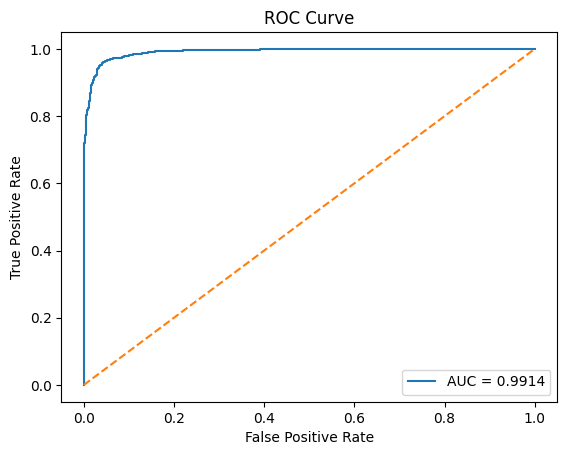

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[1540   54]
 [  83 1482]]

Classification Report:

              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      1594
         1.0       0.96      0.95      0.96      1565

    accuracy                           0.96      3159
   macro avg       0.96      0.96      0.96      3159
weighted avg       0.96      0.96      0.96      3159



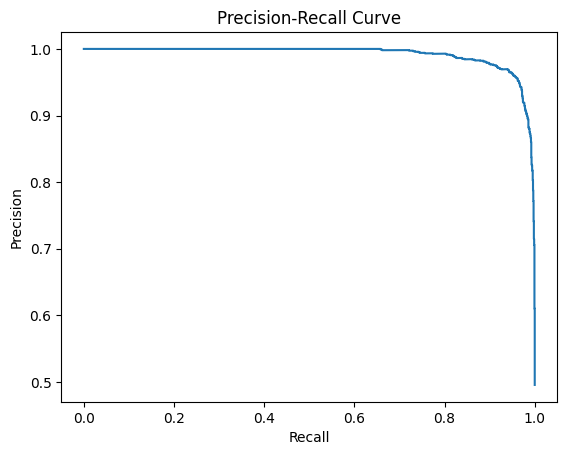

In [20]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)
print("ROC AUC:", roc_auc)

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9566 - loss: 0.1315
Test Accuracy: 0.9566318392753601
Test Loss: 0.13148948550224304
ROC AUC: 0.9914287203210123


The model achieved a test accuracy of 95.6% with an AUC of 0.99, indicating excellent separability between classes. Precision and recall were balanced across both classes (≈0.95–0.97), resulting in an overall F1-score of 0.96. The confusion matrix shows low false positive and false negative rates, suggesting stable classification performance.

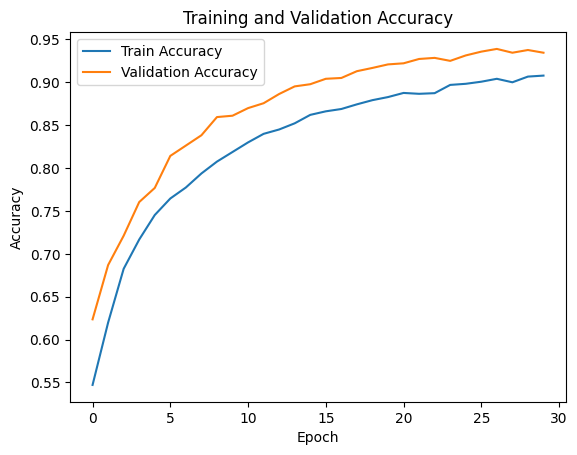

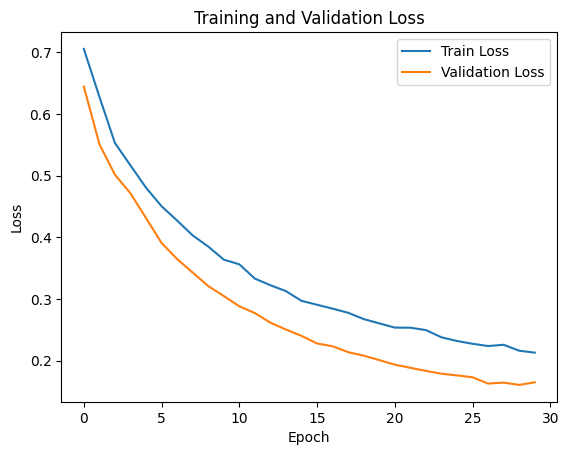

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

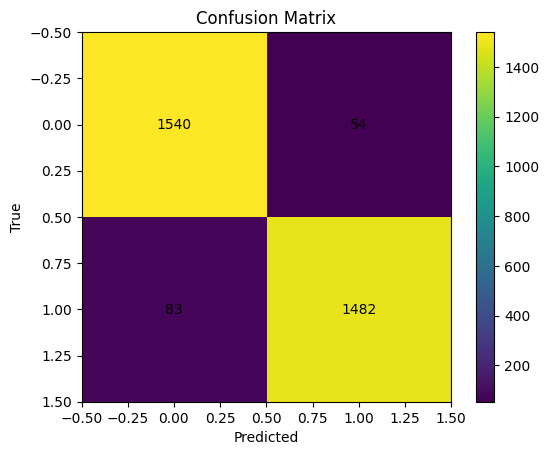

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [26]:
TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity (Recall class 1):", sensitivity)
print("Specificity (Recall class 0):", specificity)

Sensitivity (Recall class 1): 0.9469648562300319
Specificity (Recall class 0): 0.9661229611041405


In [27]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 61, 250, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 61, 250, 16)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 61, 250, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 250, 32)     │         1,952 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 250, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 250, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 62, 32)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 62, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 62, 32)      │         1,536 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 62, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 62, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 7, 32)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,853 (58.02 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 160 (640.00 B)

 Optimizer params: 9,796 (38.27 KB)

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal threshold:", optimal_threshold)

Optimal threshold: 0.44620913


Evaluate with optimal threshold:

In [29]:
y_pred_opt = (y_pred_prob > 0.44).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

cm_opt = confusion_matrix(y_test, y_pred_opt)
print("Confusion Matrix (Optimal Threshold):\n", cm_opt)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_opt))

Confusion Matrix (Optimal Threshold):
 [[1524   70]
 [  59 1506]]

Classification Report:

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      1594
         1.0       0.96      0.96      0.96      1565

    accuracy                           0.96      3159
   macro avg       0.96      0.96      0.96      3159
weighted avg       0.96      0.96      0.96      3159



Model Function and Potential Applications

In this project, a convolutional neural network (EEGNet-based architecture) was trained to classify resting-state EEG epochs recorded under two experimental conditions: Normal Sleep (NS) and Sleep Deprivation (SD). The dataset consisted of 71 participants who completed two sessions—one following normal sleep and one following sleep deprivation—during which resting-state EEG (eyes open and partially eyes closed) was recorded.

The model takes as input short EEG segments (2-second epochs) and outputs the probability that the segment belongs to either the sleep-deprived or normal sleep condition. Using an epoch-level train/validation/test split, the model achieved a test accuracy of approximately 95.6% and an area under the ROC curve (AUC) of 0.99. Precision, recall, and F1-scores were balanced across both classes, indicating stable and unbiased classification performance.

These results demonstrate that sleep deprivation induces consistent and discriminable alterations in resting-state EEG activity. The high AUC value indicates that the neural network learned a highly separable representation of the two physiological states. This suggests that sleep deprivation produces robust changes in neural oscillatory dynamics, likely involving shifts in spectral power (e.g., increased theta activity, altered alpha rhythms) and spatial patterns across electrodes. The convolutional architecture enables the model to automatically extract both temporal and spatial features from raw EEG data, without manual feature engineering.

Importantly, the current evaluation was performed using an epoch-level split, meaning that data from the same participants may appear in both training and testing sets. Therefore, the results demonstrate strong within-subject discriminability between normal sleep and sleep-deprived states. Future work should evaluate cross-subject generalization to determine how well the model performs on completely unseen individuals.



Potential Implications

The results suggest that sleep deprivation produces robust and learnable alterations in resting-state EEG dynamics. The high classification performance indicates that deep learning models can automatically extract discriminative neural patterns associated with sleep loss without manual feature engineering.

While the current evaluation was conducted using an epoch-level split, and therefore does not establish cross-subject generalizability, the findings demonstrate methodological feasibility. Future work using subject-wise validation and external datasets would be necessary to assess real-world applicability.

These results primarily contribute to methodological research, showing that convolutional neural networks are effective tools for detecting physiological state differences in EEG data.